### CRS Data Engineering Pipeline

In [1]:
# Import nacessary libs
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("../data/processed/oecd_final.parquet")
df.shape

(1698278, 7)

In [3]:
# Validate the Dataset
print(df["Year"].min(), df["Year"].max())
print(df.isnull().sum())

2015 2024
Year                      0
DonorName                 0
RecipientName             0
SectorName                0
USD_Commitment            0
ClimateMitigation    582353
ClimateAdaptation    576860
dtype: int64


In [4]:
# Extract Ethiopia Dataset
ethiopia_df = df[
    df["RecipientName"].str.contains("Ethiopia", case=False, na=False)
].copy()

print(ethiopia_df.shape)

(26686, 7)


In [5]:
ethiopia_df.isnull().sum()

Year                    0
DonorName               0
RecipientName           0
SectorName              0
USD_Commitment          0
ClimateMitigation    6360
ClimateAdaptation    6254
dtype: int64

In [6]:
ethiopia_df["ClimateAdaptation"] = pd.to_numeric(
    ethiopia_df["ClimateAdaptation"], errors="coerce"
).fillna(0)

ethiopia_df["ClimateMitigation"] = pd.to_numeric(
    ethiopia_df["ClimateMitigation"], errors="coerce"
).fillna(0)

In [7]:
ethiopia_df.isnull().sum()

Year                 0
DonorName            0
RecipientName        0
SectorName           0
USD_Commitment       0
ClimateMitigation    0
ClimateAdaptation    0
dtype: int64

“No climate objective reported” (i.e., treat as 0)
Interpretation:
- 0 → not climate-related
- 1 → significant
- 2 → principal

👉 So null ≠ missing → it’s non-climate funding

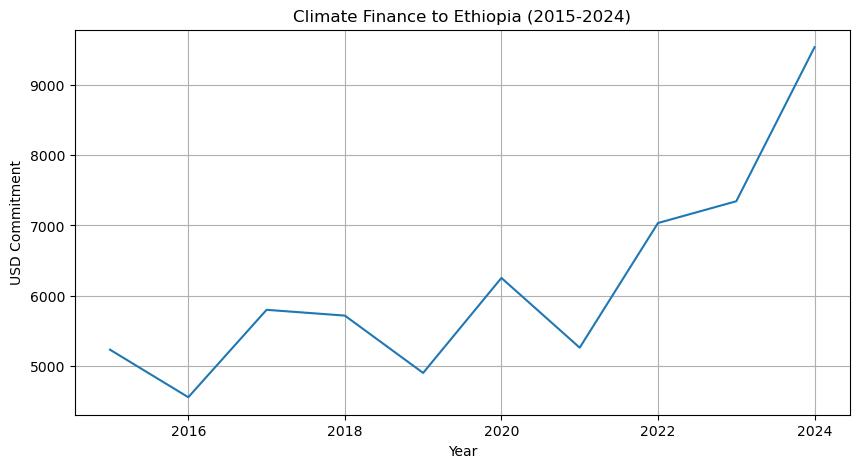

In [8]:
# Climate Finance Trend

trend = ethiopia_df.groupby("Year")["USD_Commitment"].sum()

trend.plot(figsize=(10,5))
plt.title("Climate Finance to Ethiopia (2015-2024)")
plt.ylabel("USD Commitment")
plt.grid(True)
plt.show()

In [9]:
# Measuring Volatility

trend = ethiopia_df.groupby("Year")["USD_Commitment"].sum()

volatility = trend.pct_change().std()

print("Volatility: ", volatility)

Volatility:  0.20906019169720838


Large spikes in funding appear linked to emergency response financing, suggesting reactive rather than strategic climate investment patterns.

Climate finance flows to Ethiopia show a consistent upward trend with moderate volatility, suggesting a relatively stable increase in funding rather than irregular, project-driven spikes.

In [10]:
# Top donors to Ethiopia

top_donors = (
    ethiopia_df.groupby("DonorName")["USD_Commitment"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_donors)

DonorName
International Development Association    22025.930010
United States                            12328.583241
Germany                                   2406.454199
EU Institutions                           2378.975043
United Kingdom                            2256.868503
Global Fund                               1573.870798
IMF (Concessional Trust Funds)            1566.794627
Gates Foundation                          1360.731777
Korea                                     1243.267282
Netherlands                               1133.903975
Name: USD_Commitment, dtype: float64


In [11]:
# Donor Dependency Quantifying

total = top_donors.sum()

dependency_ratio = top_donors.iloc[:2].sum() / total

print("Top 2 dependency:", dependency_ratio)

Top 2 dependency: 0.7116363172872341


#### Intrerpretation
Over 70% of climate finance to Ethiopia is concentrated among the top two donors, indicating significant dependency risk and potential vulnerability to shifts in donor priorities.

#### Policy-Level Insight
- If one donor reduces funding: major shock
- Limits negotiation power
- Reduces diversification

The high concentration of funding among a small number of donors highlights a structural dependency risk, underscoring the need for diversification of climate finance sources, particularly ahead of COP32.

In [12]:
# Sector Distribution

sector_dist = (
    ethiopia_df.groupby("SectorName")["USD_Commitment"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(sector_dist)

SectorName
VIII.1. Emergency Response                                   10266.302063
III.1.a. Agriculture                                          5764.120169
I.6. Other Social Infrastructure & Services                   4949.581412
I.2.b. Basic Health                                           4206.020517
I.3. Population Policies/Programmes & Reproductive Health     3888.619190
I.5.a. Government & Civil Society-general                     2921.387934
IV.2. Other Multisector                                       2578.013096
I.4. Water Supply & Sanitation                                2552.864007
II.4. Banking & Financial Services                            2540.936968
II.1. Transport & Storage                                     2384.826588
Name: USD_Commitment, dtype: float64


While agriculture and water sectors receive substantial funding aligned with Ethiopia’s resilience priorities, a large share of financing is concentrated in emergency response, indicating a reactive funding structure rather than long-term climate investment.

Despite relatively stable growth in climate finance, the concentration of funding in emergency response sectors suggests that a portion of financing remains reactive rather than fully aligned with long-term resilience planning.

In [14]:
# Sector Concentration Ration: Over-Investment measurment
sector_share = sector_dist / sector_dist.sum()
print(sector_share.head())

SectorName
VIII.1. Emergency Response                                   0.244130
III.1.a. Agriculture                                         0.137069
I.6. Other Social Infrastructure & Services                  0.117700
I.2.b. Basic Health                                          0.100018
I.3. Population Policies/Programmes & Reproductive Health    0.092470
Name: USD_Commitment, dtype: float64


In [15]:
sector_share.max()

0.24412960195897318

In [20]:
# Adaptation vs Mitigation

ethiopia_df["ClimateMitigation"] = pd.to_numeric(
    ethiopia_df["ClimateMitigation"], errors="coerce"
)

ethiopia_df["ClimateAdaptation"] = pd.to_numeric(
    ethiopia_df["ClimateAdaptation"], errors="coerce"
)

adaptation = ethiopia_df[ethiopia_df["ClimateAdaptation"] > 0]["USD_Commitment"].sum()
mitigation = ethiopia_df[ethiopia_df["ClimateMitigation"] > 0]["USD_Commitment"].sum()

print("Adaptation: ", adaptation)
print("Mitigation: ", mitigation)

Adaptation:  6868.122885
Mitigation:  3123.2604220000003


In [24]:
# Calculate Ratio

ratio = adaptation / (adaptation + mitigation)

print("Adaptation Share: ", ratio)

Adaptation Share:  0.6874046039438971


#### Interpretation:
    - 60% → adaptation-heavy
    - <40% → mitigation-heavy
    
Ethiopia receives predominantly adaptation-focused climate finance, reflecting its vulnerability to climate impacts; however, relatively lower mitigation investment may limit long-term participation in carbon markets.

Climate finance to Ethiopia has increased steadily over the past decade with moderate volatility, indicating relatively stable growth. However, funding remains highly concentrated among a small number of donors, with over 70% coming from the top two, creating dependency risks.